In [1]:
from astropy.io import fits

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import stats as ss
from scipy import signal
from scipy.io import readsav
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA

from tqdm import tqdm

import tools as t

## Extract data

In [2]:
# load files
path_data = '../data/sim_series/'
N_files = 20  # 20 temporal series (from 0 to 19)
data_spectra = []
data_rv = []
for i in range(N_files):  # files have the same name, only number changes
    data_spectra.append(fits.getdata(path_data + f'flux_norm_6173_lionel_tau1_spatialscaling1_sansrotation_serie{i}.fits'))
    data_rv.append(readsav(path_data + f'res_rv_bis_6173_lionel_tau1_scaling1_sansrot_serie{i}.sav'))
data_spectra = np.array(data_spectra)
data_rv = np.array(data_rv)
data_rv[0].keys()

dict_keys(['rv_gauss', 'rv_correl', 'rv_deriv', 'xbiss', 'ybiss', 'l_true', 'lambd', 'flux_moy'])

In [3]:
# check shape
print(data_spectra.shape)

(20, 3686, 122)


data_spectra[ i ]: matrix with 3686 spectra of 122 elements each \
data_rv[ i ]: dictionary

In [4]:
c = 3e8  # speed of light [m/s]
# extract data
wl = np.array(data_rv[0]['lambd'])  # same wavelength grid for all time series (verified)
times = np.arange(0, len(data_spectra[0]) * 144, 144) / 60 / 24  # time in days, same for all time series
times_sec = times * 86400  # time in sec
# extract RV data
rv_ccf = []
for i in range(N_files):
    rv_ccf.append(data_rv[i]['rv_correl'])
wl = np.array(wl)
rv_ccf = np.array(rv_ccf)

### Preprocessing

In [5]:
# calculate the mean spectra
mean_spec = np.array([np.mean(i, axis=0) for i in data_spectra])  # list of mean spectrum for each TS
d_S0 = np.array([np.gradient(i, wl) for i in mean_spec])  # list of derivative of the mean spectra for each TS

In [ ]:
S_f = []  # array of matrices
D_vectors = []  # array of Doppler vectors

for i in range(N_files):  # for each TS
    s, v = t.subtract_D(wl, data_spectra[i], c=c)  # take out projection over the Doppler vector
    S_f.append(s)
    D_vectors.append(v)

S_f = np.array(S_f)
D_vectors = np.array(D_vectors)

## Calculate RV by template matching

In [7]:
# calculate radial velocity by template matching
C_0 = 1000  # continuum constant
rv_tm = []  # list of RV vector for each TS
for j in range(N_files):  # for each TS
    rv_j = []
    for k in range(len(times)):  # for each spectrum
        rv_j.append(t.calculate_rv(wl, mean_spec[j], data_spectra[j][k], C_0))  # calculate RV by TM
    rv_tm.append(np.array(rv_j))
rv_tm = np.array(rv_tm)

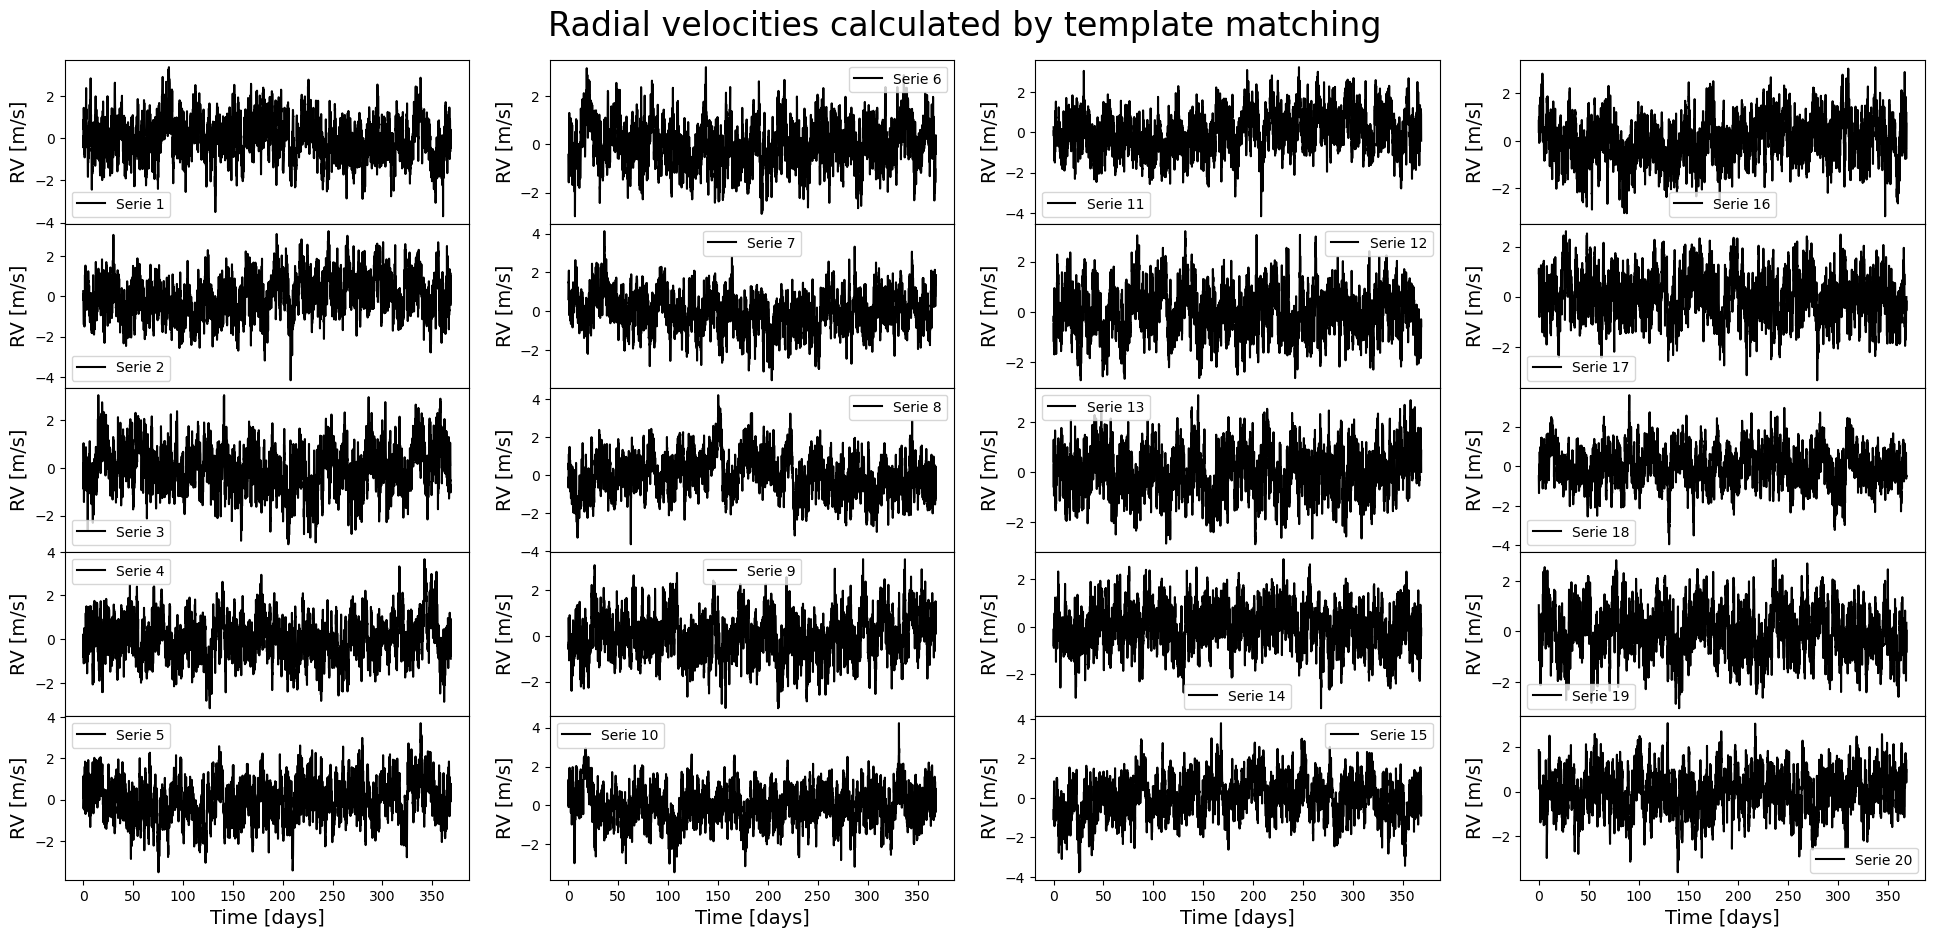

In [8]:
# plot RV for each TS
rows = 5
cols = 4
fig, axs = plt.subplots(rows, cols, figsize=(24, 10), sharex=True)
fig.suptitle('Radial velocities calculated by template matching', size=24)

r = 0  # row counter
k = -1  # column counter

for i in range(N_files):  # iterate over the N_files time series of spectra
    if i % rows == 0:  # if the column is filled, advance to the next one
        k += 1  # advance to the next column
        r = 0  # reset row
    if (i + 1) % rows == 0:  # set label only in the last row of each column
        axs[r][k].set_xlabel('Time [days]', size=14)
    axs[r][k].plot(times, rv_tm[i], color='k', label=f'Serie {i+1}')
    axs[r][k].set_ylabel('RV [m/s]', size=14)
    axs[r][k].legend()
    r += 1  # advance to the next row

plt.subplots_adjust(hspace=0, top=.93)
plt.show()

## RV Periodograms

In [9]:
# calculate RV periodograms
dt = times[1] - times[0]  # delta time in days
dt_sec = times_sec[1] - times_sec[0]  # delta time in seconds

# power spectrum
ffts = []  # FT of each TS
power_specs = []  # PS of each TS

for i in range(N_files):  # for each TS
    ft_tm, ps_tm, freq_hz = t.calculate_periodogram(times_sec, rv_tm[i])  # calculate periodograms using RV calculated by TM
    ffts.append(ft_tm)
    power_specs.append(ps_tm)

# calculate frequencies
freq_days = freq_hz * 86400  # frequency in days^-1, same for all power spectra (as the time array is the same for all TS)
mask = freq_days > 0  # keep only positive values

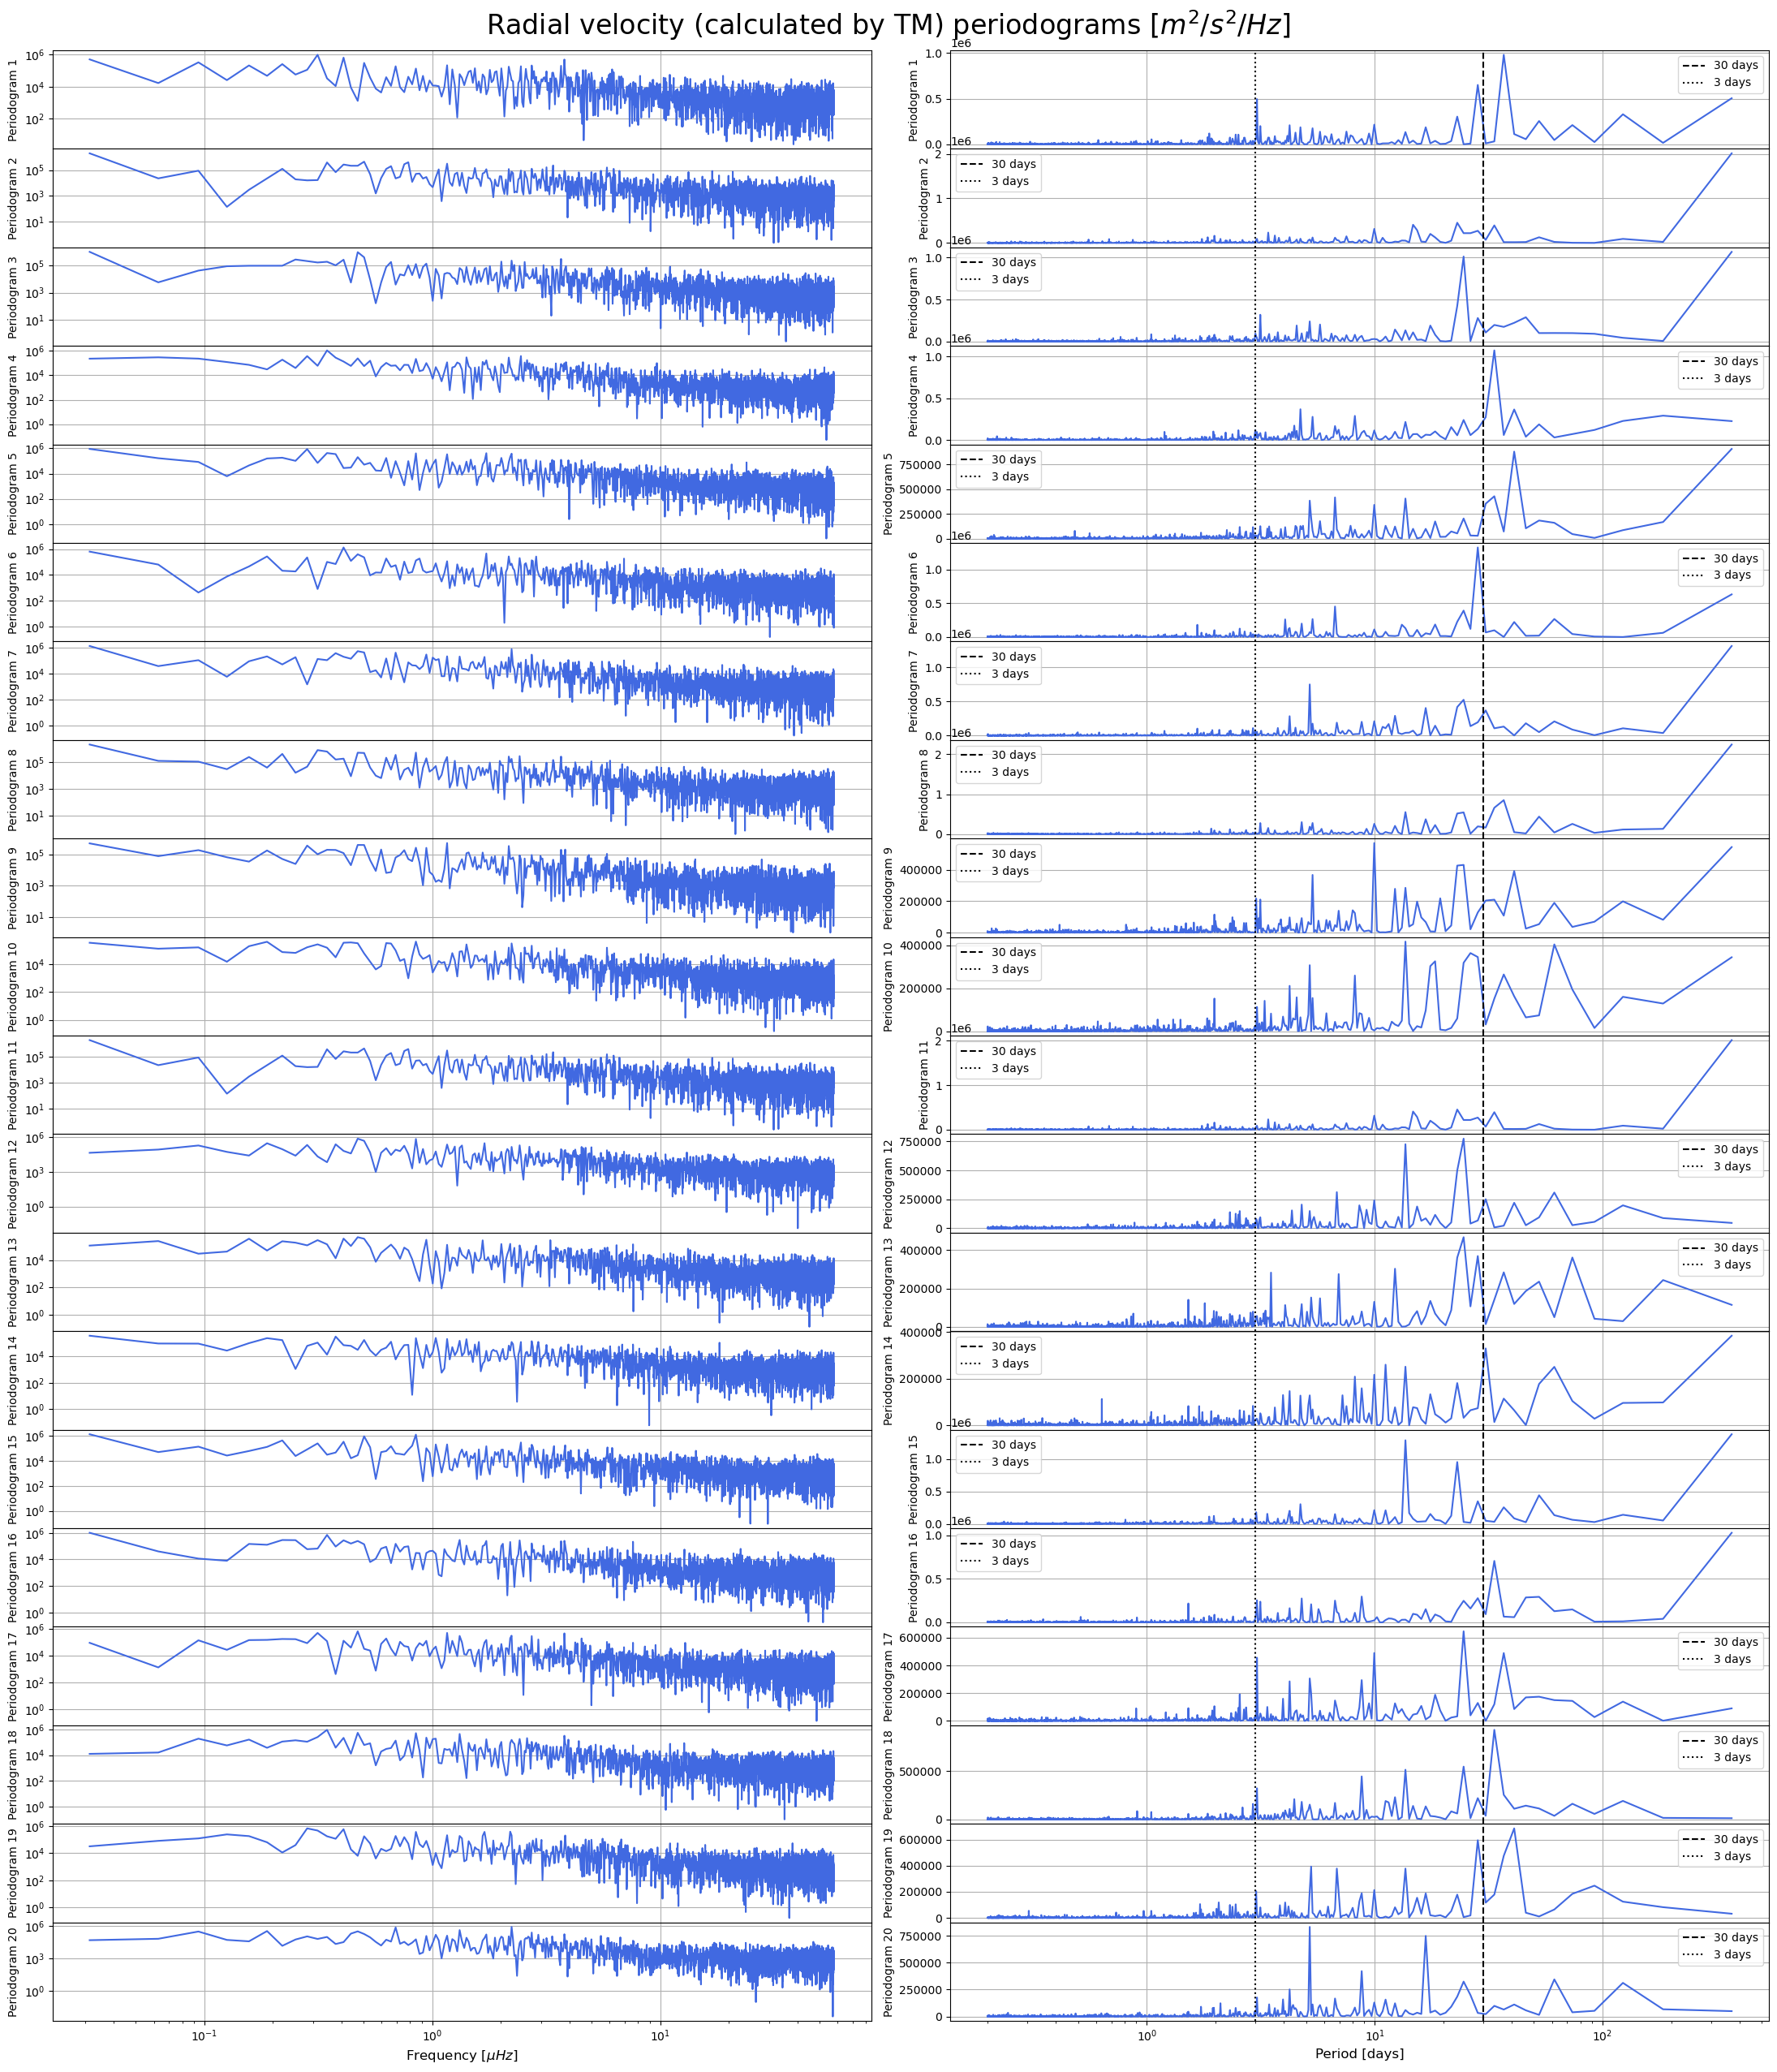

In [10]:
# plot RV periodograms
fig, axs = plt.subplots(N_files, 2, figsize=(22, 26), sharex='col')
fig.suptitle(r'Radial velocity (calculated by TM) periodograms [$m^2/s^2/Hz$]', size=24)

for i in range(N_files):
    # Frequency periodogram
    axs[i][0].plot(freq_hz[mask] * 10**6, power_specs[i][mask], color='royalblue')
    axs[i][0].set_yscale('log')
    axs[i][0].set_xscale('log')
    axs[i][0].set_ylabel(f'Periodogram {i+1}', size=10)
    axs[i][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
    axs[i][0].grid()

    # Periodogram
    axs[i][1].plot(1 / freq_days[mask], power_specs[i][mask], color='royalblue')
    axs[i][1].axvline(30, color='k', linestyle='--', label='30 days')
    axs[i][1].axvline(3, color='k', linestyle=':', label='3 days')
    axs[i][1].set_xscale('log')
    axs[i][1].set_xlabel('Period [days]', size=12)
    axs[i][1].set_ylabel(f'Periodogram {i+1}', size=10)
    axs[i][1].grid()
    axs[i][1].legend()

fig.tight_layout()
plt.subplots_adjust(hspace=0, top=.96)
plt.show()

### Mean periodograms

In [11]:
# split time series into chunks
n_chunks = 19
time_chunks = np.array_split(times_sec, n_chunks)  # same array for all chunks
tm_chunks  = [np.array_split(i, n_chunks) for i in rv_tm]  # list of N_files lists of chunks

# do FT for each chunk
pg_chunked = []  # list of N_files lists (one for each TS) of n_chunks dictionaries (one for each chunk)
for i in range(N_files):
    periodograms = {}
    for j in range(n_chunks):  # iterate over chunk index
        # power spectrum
        ft_tm_j, ps_tm_j, freq_hz_j = t.calculate_periodogram(time_chunks[j], tm_chunks[i][j])  # periodogram of the RV chunk

        # calculate frequencies
        mask_j = freq_hz_j > 0  # same mask for all periodograms

        periodograms[j] = [ft_tm_j, ps_tm_j, freq_hz_j, mask_j]  # save periodogram elements
    pg_chunked.append(periodograms)

In [12]:
# array of mean power spectra (for each TS)
mean_power_tm = np.array([np.mean([j[i][1] for i in range(n_chunks)], axis=0) for j in pg_chunked])  # j is a dict, j[i] is a list of elements of the chunk i of the TS j, j[i][1] is a PS

# save important information
m       = pg_chunked[0][0][-1]  # mask (same for all TS)
f_hz    = np.array(pg_chunked[0][0][-2][m]) # frequency in days^-1 (same for all TS)
f_days  = f_hz * 86400 # frequency in Hz (same for all TS)
df      = f_days[1] - f_days[0]  # frequency step in days
df_hz   = f_hz[1] - f_hz[0]  # frequency step in Hz
pgram_tm = np.array([j[m] for j in mean_power_tm])  # array of periodograms, one for each TS

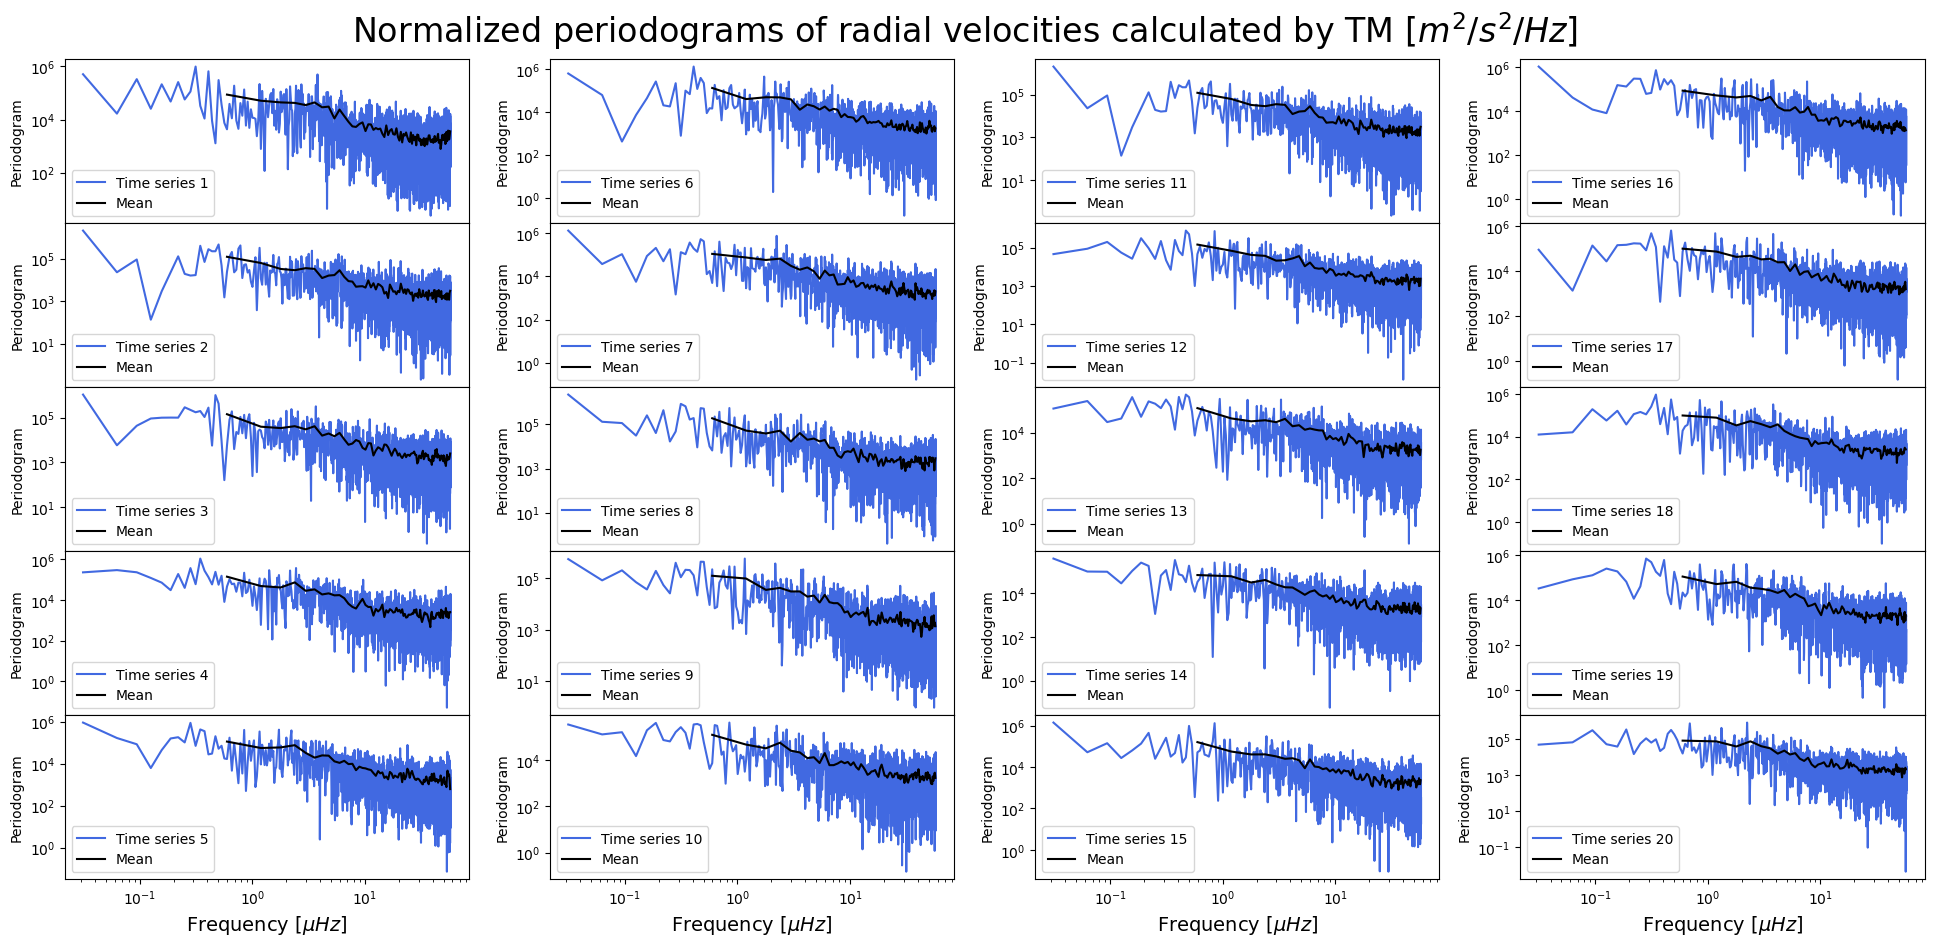

In [13]:
# plot mean periodograms
rows = 5
cols = 4
fig, axs = plt.subplots(rows, cols, figsize=(24, 10), sharex=True)
fig.suptitle(r'Normalized periodograms of radial velocities calculated by TM [$m^2/s^2/Hz$]', size=24)

r = 0
k = -1

for i in range(N_files):  # iterate over the N_files time series of spectra
    if i % rows == 0:  # if the column is filled, advance to the next one
        k += 1  # advance to the next column
        r = 0  # reset row
    if (i + 1) % rows == 0:  # set label only in the last row of each column
        axs[r][k].set_xlabel(r'Frequency [$\mu Hz$]', size=14)
    axs[r][k].loglog(freq_hz[mask] * 10**6, power_specs[i][mask], color='royalblue', label=f'Time series {i+1}')  # original periodogram
    axs[r][k].loglog(f_hz * 10**6, pgram_tm[i], color='k', label='Mean')  # mean periodogram
    axs[r][k].set_ylabel('Periodogram', size=10)
    axs[r][k].legend()
    r += 1  # advance to the next row

plt.subplots_adjust(hspace=0, top=.93)
plt.show()

### Harvey fit

In [14]:
params = []
count = 1
for i in pgram_tm:
    # initial guess
    p0 = [
        np.std(rv_tm),                   # a -> amplitude (total power)
        5 / 10**6,                       # b -> turnover frequency from the plot above (where the power starts to decay)
        2.0,                             # c -> classical value
        np.median(i[f_hz * 10**6 > 10])  # d -> median of the noisy part from the plot above
    ]

    # fit
    try:
        p, _ = curve_fit(t.harvey_unpacked, f_hz[1:], i[1:], p0=p0)  # least squares fit
        p_dict = {'a': p[0], 'b': p[1], 'c': p[2], 'd': p[3]}
        params.append(p_dict)
    except Exception as e:
        print(f'Error with spectrum number {count}:')
        print(e)
        params.append({'a': np.nan, 'b': np.nan, 'c': np.nan, 'd': np.nan})
    count += 1

a = np.array([i['a'] for i in params])
b = np.array([i['b'] for i in params])
c = np.array([i['c'] for i in params])
d = np.array([i['d'] for i in params])

Error with spectrum number 9:
Optimal parameters not found: Number of calls to function has reached maxfev = 1000.


/net/CLUSTER/VAULT/users/elefevre-forjan/Internship/scripts_final/tools.py:247: RuntimeWarning: invalid value encountered in power
  return a / (f * b) / (1 + (nu / b)**c) + d


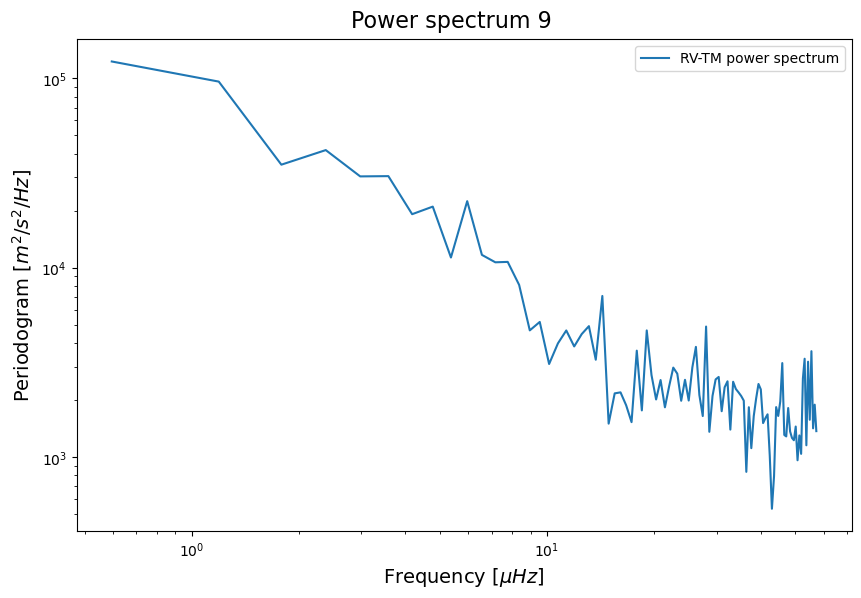

In [15]:
# show problematic periodogram
i = 8  # index of the TS
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f'Power spectrum {i+1}', size=16)

ax.loglog(f_hz * 10**6, pgram_tm[i], label='RV-TM power spectrum')
ax.set_xlabel(r'Frequency [$\mu Hz$]', size=14)
ax.set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
ax.legend()

plt.subplots_adjust(top=.93)
plt.show()

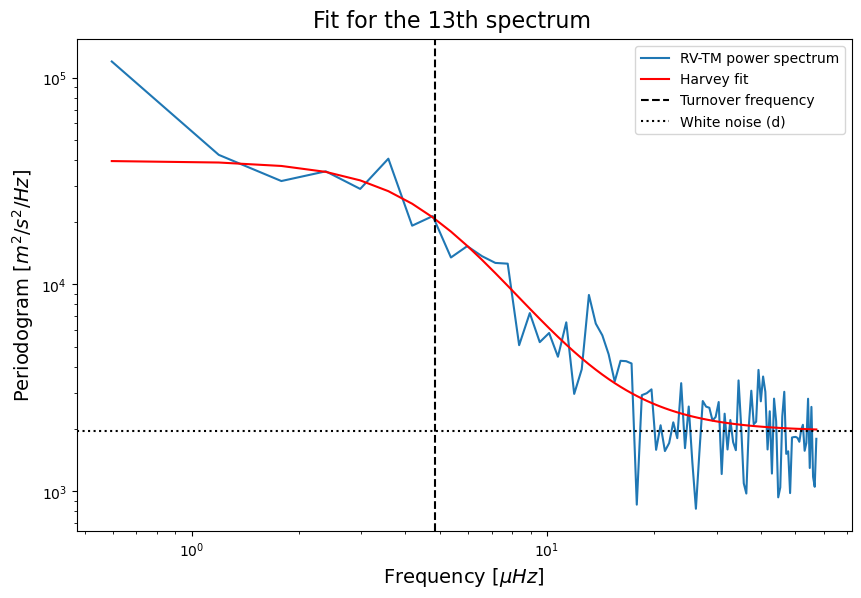

In [16]:
# show fit
i = 12  # index of the TS
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f'Fit for the {i+1}th spectrum', size=16)

ax.loglog(f_hz * 10**6, pgram_tm[i], label='RV-TM power spectrum')
ax.loglog(f_hz * 10**6, t.harvey([a[i], b[i], c[i], d[i]], f_hz), label='Harvey fit', color='red')
ax.axvline(b[i] * 10**6, color='k', linestyle='--', label='Turnover frequency')
ax.axhline(d[i], color='k', linestyle=':', label='White noise (d)')
ax.set_xlabel(r'Frequency [$\mu Hz$]', size=14)
ax.set_ylabel(r'Periodogram [$m^2/s^2/Hz$]', size=14)
ax.legend()

plt.subplots_adjust(top=.93)
plt.show()

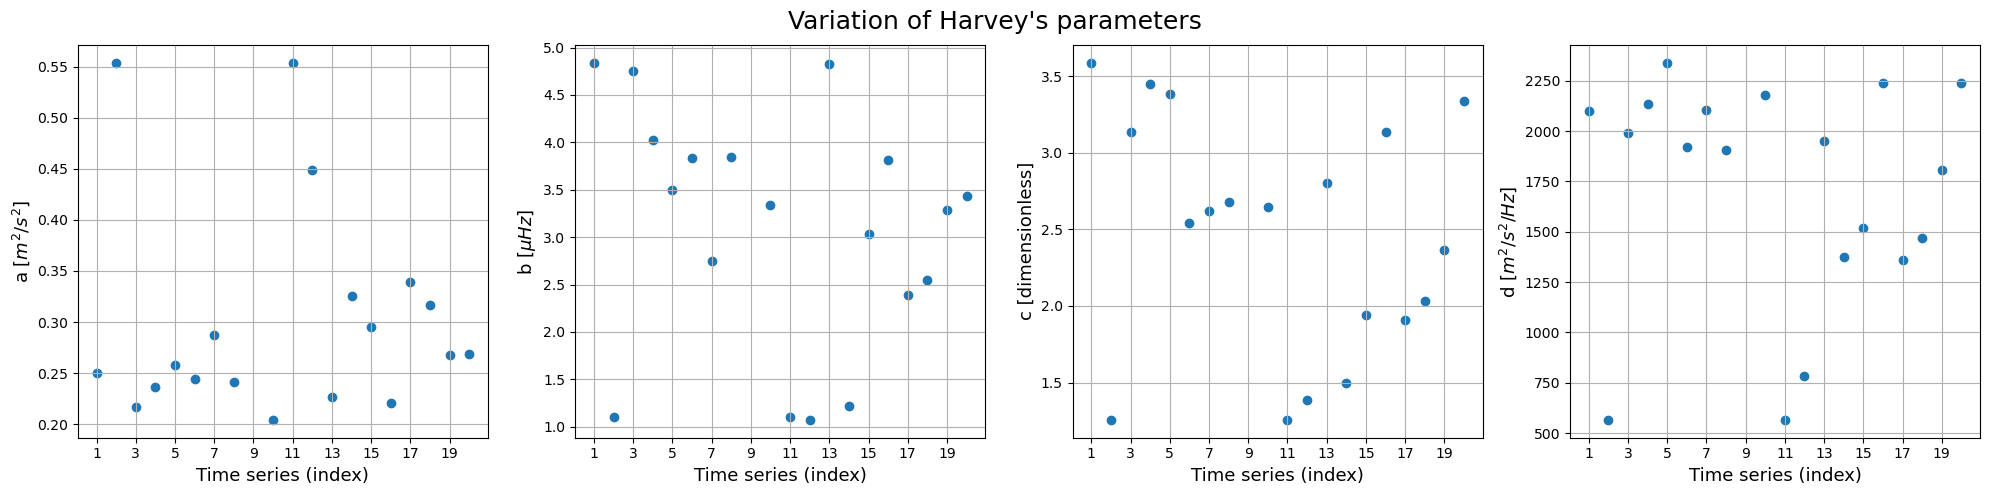

In [17]:
x = np.arange(1, N_files + 1, 1)

fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharex=True)
fig.suptitle("Variation of Harvey's parameters", size=18)

axs[0].scatter(x, a)
axs[0].set_xlabel('Time series (index)', size=13)
axs[0].set_ylabel(r'a [$m^2/s^2$]', size=13)
axs[0].set_xticks(x[::2])
axs[0].grid()

axs[1].scatter(x, b * 10**6)
axs[1].set_xlabel('Time series (index)', size=13)
axs[1].set_ylabel(r'b [$\mu Hz$]', size=13)
axs[1].grid()

axs[2].scatter(x, c)
axs[2].set_xlabel('Time series (index)', size=13)
axs[2].set_ylabel('c [dimensionless]', size=13)
axs[2].grid()

axs[3].scatter(x, d)
axs[3].set_xlabel('Time series (index)', size=13)
axs[3].set_ylabel(r'd [$m^2/s^2/Hz$]', size=13)
axs[3].grid()
#axs[3].set_yscale('log')

fig.tight_layout()
plt.subplots_adjust(top=.91)
plt.show()

## Apply PCA

In [18]:
# apply double centering to each S_f matrix
spectra_centered = np.array([t.double_centering(i) for i in S_f])

In [19]:
# apply PCA to the centered matrix
n_components = 20

pcs_ts = []  # list of N_files lists of of principal components
loadings_ts = []  # list of loadings of all PCs for each TS
scores_ts = []  # list of scores of all PCs for each TS

for i in spectra_centered:  # each i is a double-centered matrix (corresponding to each TS)
    pca_flux_i = PCA(n_components=n_components)  # create PCA object
    pcs_i = pca_flux_i.fit_transform(i)  # fit the model with spectra_centered and apply the dimensionality reduction
    pcs_ts.append(pcs_i)  # save PCs
    loadings_ts.append(pca_flux_i.components_)  # save loadings
    scores_ts.append(np.array([pcs_i[:, j] for j in range(n_components)]))  # save scores

pcs_ts = np.array(pcs_ts)
loadings_ts = np.array(loadings_ts)
scores_ts = np.array(scores_ts)

In [20]:
# component significance
# multiple realizations allow to calculate error bars
n_realizations = 20
snr = 40000
sigma = 1 / snr  # std of the gaussian noise that will be added to the spectra

# list of max mean and std for each PC: [(max_avg_1, max_std_1), (max_avg_2, max_std_2), ..., (max_avg_n, max_std_n)]
mean_maxes = np.array([t.calculate_pca_significance(n_realizations, n_components, wl, i, sigma, bar=False) for i in data_spectra])

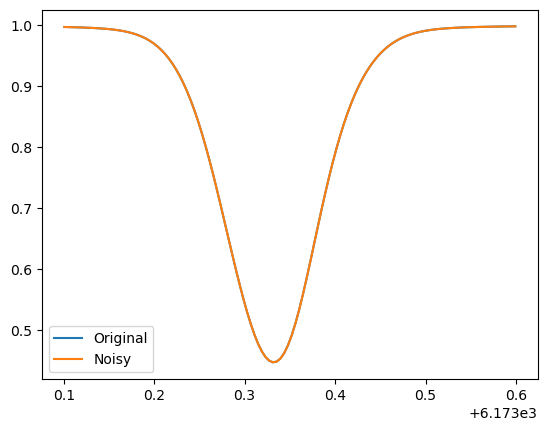

In [21]:
# show noise (example for one spectrum)
spectra_noisy = np.array([i + np.random.normal(0, sigma, len(wl)) for i in data_spectra])  # add gaussian noise to the original data
plt.plot(wl, data_spectra[0][0], label='Original')
plt.plot(wl, spectra_noisy[0][0], label='Noisy')
plt.legend()
plt.show()

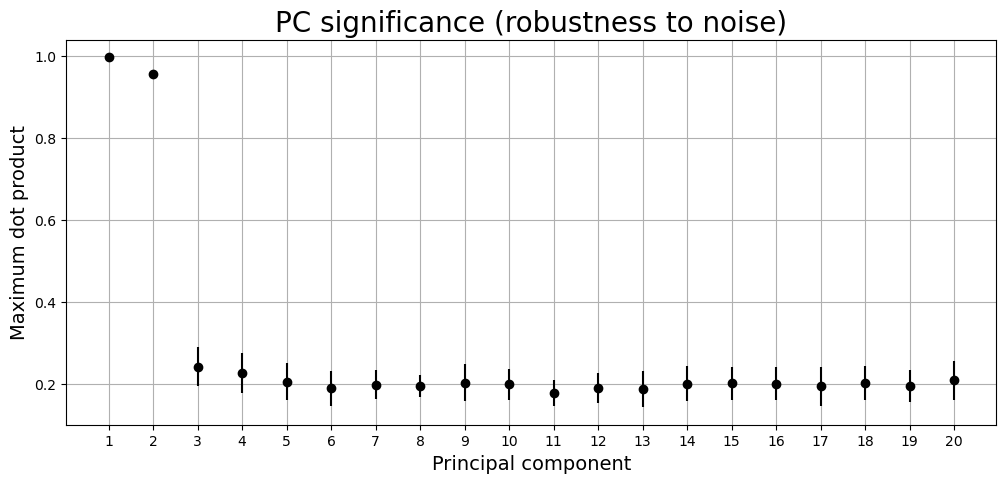

In [22]:
# show PC significance
x = np.linspace(1, N_files, N_files)

fig, ax = plt.subplots(figsize=(12, 5))
ax.grid()
ax.errorbar(np.linspace(1, n_components, n_components), mean_maxes[0][:, 0], mean_maxes[0][:, 1], fmt='o', color='k', ecolor='k')
ax.set_title('PC significance (robustness to noise)', size=20)
ax.set_xlabel('Principal component', size=14)
ax.set_ylabel('Maximum dot product', size=14)
ax.set_xticks(x)
plt.show()

In [23]:
# calculate median correlation coefficient of each PC

corr_ts = []  # r between each PC and the RV for each TS
for i in range(N_files):  # for each TS
    corr_i = []
    scores_i = scores_ts[i]  # scores of the i-th TS
    rv_i = rv_tm[i]  # RV of the i-th TS
    for sco in scores_i:  # for each set of scores (i.e. for each PC)
        corr_i.append(ss.pearsonr(rv_i, sco)[0])  # r(RV, PC)
    corr_ts.append(corr_i)
corr_ts = np.array(corr_ts)

corr_med = np.median(corr_ts, axis=0)  # median r for each PC
corr_p16 = np.array([np.percentile(corr_ts[:, i], 16) for i in range(N_files)])  # percentile 16 for each PC
corr_p84 = np.array([np.percentile(corr_ts[:, i], 84) for i in range(N_files)])  # percentile 84 for each PC
# compute asymmetric error bars
yerr = np.array([np.array(corr_med) - np.array(corr_p16), np.array(corr_p84) - np.array(corr_med)])

corr_mean = np.mean(corr_ts, axis=0)
corr_std = np.std(corr_ts, axis=0)

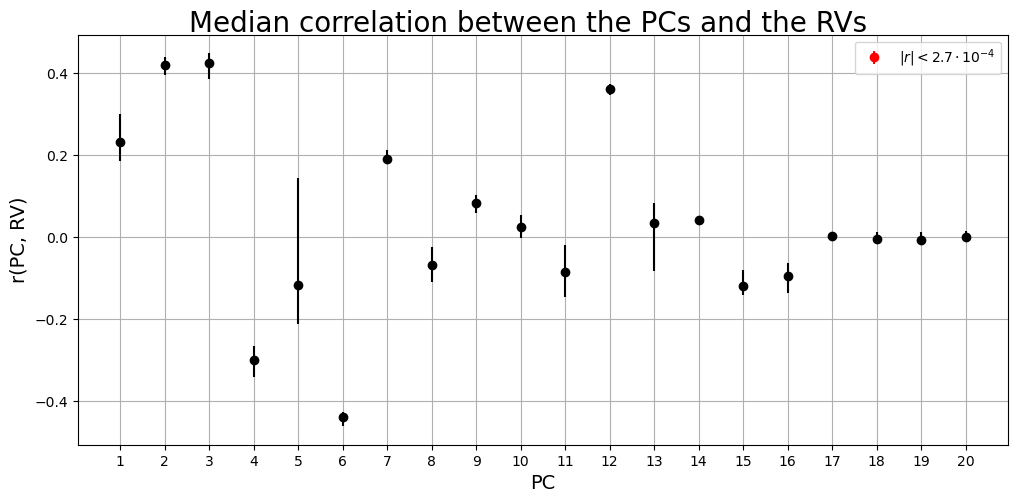

In [24]:
# show results
threshold = 1/3686  # correlations weaker than the threshold are shown in red
yerr_lower = yerr[0]
yerr_upper = yerr[1]

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Median correlation between the PCs and the RVs', size=20)

# plot correlation for each PC
ax.errorbar(x, corr_med, yerr=yerr, color='k', ecolor='k', fmt='o')

# condition for red points
red_mask = np.abs(corr_med) < threshold

# plot red points (if any)

ax.errorbar(x[red_mask], corr_med[red_mask], yerr=yerr[:, red_mask], color='red', ecolor='red', fmt='o', label=r'$|r| < 2.7 \cdot 10^{-4}$', zorder=3)

ax.set_xlabel('PC', size=14)
ax.set_xticks(x)
ax.set_ylabel('r(PC, RV)', size=14)
ax.grid(zorder=-1)

ax.legend()

plt.subplots_adjust(top=.93)
plt.show()

In [25]:
# calculate median correlation coefficient of each PC (noisy case)

# create noisy TS
sigma = 9000

ts_noisy = data_spectra + np.random.normal(
    loc=0,
    scale=sigma,
    size=data_spectra.shape
)

# calculate rv
mean_spec_noisy = np.array([np.mean(i, axis=0) for i in ts_noisy])  # list of mean spectrum for each TS
C_0 = 1000  # continuum constant
rv_noisy = []  # list of RV vector for each TS
for j in range(N_files):  # for each TS
    rv_j = []
    for k in range(len(times)):  # for each spectrum
        rv_j.append(t.calculate_rv(wl, mean_spec_noisy[j], ts_noisy[j][k], C_0))  # calculate RV by TM
    rv_noisy.append(np.array(rv_j))
rv_noisy = np.array(rv_noisy)

# preprocessing
c=3e8
S_noisy = []
D_noisy = []
for i in range(N_files):  # for each TS
    s, v = t.subtract_D(wl, ts_noisy[i], c=c)  # take out projection over the Doppler vector
    S_noisy.append(s)
    D_noisy.append(v)
spectra_noisy_centered = np.array([t.double_centering(i) for i in S_noisy])  # apply double centering to each S_noisy matrix

# PCA
pcs_noisy = []  # list of N_files lists of of principal components
loadings_noisy = []  # list of loadings of all PCs for each TS
scores_noisy = []  # list of scores of all PCs for each TS

for i in spectra_noisy_centered:  # each i is a double-centered matrix (corresponding to each TS)
    pca_flux_i = PCA(n_components=n_components)  # create PCA object
    pcs_i = pca_flux_i.fit_transform(i)  # fit the model with spectra_centered and apply the dimensionality reduction
    pcs_noisy.append(pcs_i)  # save PCs
    loadings_noisy.append(pca_flux_i.components_)  # save loadings
    scores_noisy.append(np.array([pcs_i[:, j] for j in range(n_components)]))  # save scores

pcs_noisy = np.array(pcs_noisy)
loadings_noisy = np.array(loadings_noisy)
scores_noisy = np.array(scores_noisy)

# correlation (noisy)
corr_noisy = []  # r between each PC and the RV for each TS
for i in range(N_files):  # for each TS
    corr_i = []
    scores_i = scores_noisy[i]  # scores of the i-th TS
    rv_i = rv_noisy[i]  # RV of the i-th TS
    for sco in scores_i:  # for each set of scores (i.e. for each PC)
        corr_i.append(ss.pearsonr(rv_i, sco)[0])  # r(RV, PC)
    corr_noisy.append(corr_i)
corr_noisy = np.array(corr_noisy)

corr_noisy_med = np.median(corr_noisy, axis=0)  # median r for each PC
corr_noisy_p16 = np.array([np.percentile(corr_noisy[:, i], 16) for i in range(N_files)])  # percentile 16 for each PC
corr_noisy_p84 = np.array([np.percentile(corr_noisy[:, i], 84) for i in range(N_files)])  # percentile 84 for each PC
# compute asymmetric error bars
yerr_noisy = np.array([np.array(corr_noisy_med) - np.array(corr_noisy_p16), np.array(corr_noisy_p84) - np.array(corr_noisy_med)])

corr_noisy_mean = np.mean(corr_noisy, axis=0)
corr_noisy_std = np.std(corr_noisy, axis=0)

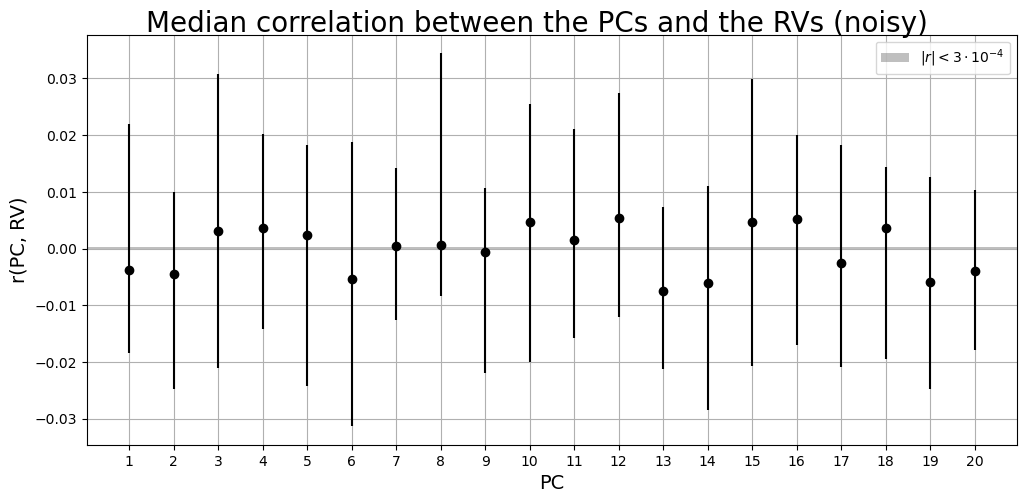

In [26]:
threshold = 1/3686
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Median correlation between the PCs and the RVs (noisy)', size=20)

ax.errorbar(x, corr_noisy_med, yerr=yerr_noisy, color='k', ecolor='k', fmt='o')
ax.set_xlabel('PC', size=14)
ax.set_xticks(x)
ax.set_ylabel('r(PC, RV)', size=14)
ax.grid(zorder=-1)
ax.axhspan(-threshold, threshold, facecolor='gray', alpha=0.5, label=r'$|r| < 3 \cdot 10^{-4} $')
ax.legend()

plt.subplots_adjust(top=.93)
plt.show()

## Linear fit

Fit RV data using multiple PCs, tried only on TS1.

The fit is $RV = I \cdot x$

In [27]:
file = 0  # pick one file to use from now on

# extract data from the file
spectra = data_spectra[file]
pcs = pcs_ts[file]
scores = scores_ts[file]
loadings = loadings_ts[file]
rv = rv_tm[file]

# power spectrum
pgs = np.array([t.calculate_periodogram(times_sec, scores[i]) for i in range(n_components)])  # calculate periodograms
ft, ps, freq = pgs[:, 0], pgs[:, 1], pgs[:, 2]  # save FT, PS and frequencies

In [29]:
# calculate chi2 = ||RV - I*x||^2
k = 12  # example
chi2 = t.calculate_chi2(k, scores, rv)

# check result
print(chi2)

219.3137868026355


In [30]:
# calculate chi^2 from random values instead of scores, for comparison
# put random values in place of the scores
random_matrix = np.random.randn(len(rv), k).T
# calculate chi2
chi2_rand = t.calculate_chi2(k, random_matrix, rv)
# check result
print(chi2_rand)

3293.745787362588


In [31]:
# chi2 for several values of k
chi2_list = []
k_list = np.arange(1, n_components + 1, 1)

N_r = 1000  # number of random realizations
A_random_list = np.array([np.random.randn(n_components, len(rv)) for i in range(N_r)])  # create a list of N_r matrices of size n_comps * len(rv)

for k in k_list:  # for each number of PCs
    # real scores
    chi2 = t.calculate_chi2(k, scores, rv)
    
    # random scores
    chi2_rand_list = []
    for j in range(N_r):  # iterate over realizations
        random_matrix = A_random_list[j]  # get random scores
        chi2_rand = t.calculate_chi2(k, random_matrix, rv)  # calculate chi2
        chi2_rand_list.append(chi2_rand)
    chi2_rand = np.mean(chi2_rand_list)  # mean chi2 over realizations
    chi2_rand_std = np.std(chi2_rand_list)  # std chi2 over realizations
    chi2_list.append([chi2, chi2_rand, chi2_rand_std])

chi2_list = np.array(chi2_list)

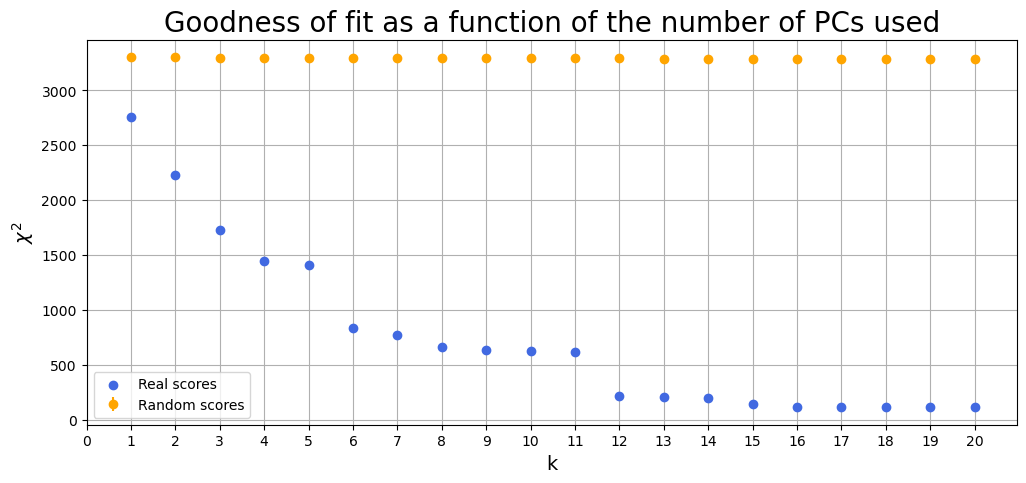

In [32]:
# show chi2
fig, ax = plt.subplots(figsize=(12, 5))

ax.grid()
ax.scatter(k_list, chi2_list[:, 0], label='Real scores', color='royalblue', zorder=2)
ax.errorbar(k_list, chi2_list[:, 1], yerr=chi2_list[:, 2], label='Random scores', color='orange', ecolor='orange', fmt='o', zorder=2)
ax.set_title('Goodness of fit as a function of the number of PCs used', size=20)
ax.set_xlabel('k', size=14)
ax.set_ylabel(r'$\chi^2$', size=14)
ax.set_xticks(np.arange(0, n_components + 1, 1))
ax.legend()
#ax.set_yscale('log')
plt.show()

In [33]:
# test with noisy spectra
wl_ex = wl
snr = 9000
ex_noisy = spectra + np.random.normal(0, 1/snr, spectra.shape)  # add noise to the TS

# calculate RV
mean_spec_noisy = np.mean(ex_noisy, axis=0)
rv_noisy = np.array([t.calculate_rv(wl_ex, mean_spec_noisy, row, C_0) for row in ex_noisy])
# preprocessing
S_f_noisy, D_noisy = t.subtract_D(wl_ex, ex_noisy, c=3e8)
spectra_centered_noisy = t.double_centering(S_f_noisy)
# apply PCA
pca_flux_noisy = PCA(n_components=n_components)  # create PCA object
pcs_noisy = pca_flux_noisy.fit_transform(spectra_centered_noisy)
scores_noisy = np.array([pcs_noisy[:, j] for j in range(n_components)])

In [34]:
# calculate chi2
chi2_list_noisy = []

for k in k_list:
    # noisy scores
    chi2 = t.calculate_chi2(k, scores_noisy, rv_noisy)
    chi2_list_noisy.append(chi2)
chi2_list_noisy = np.array(chi2_list_noisy)

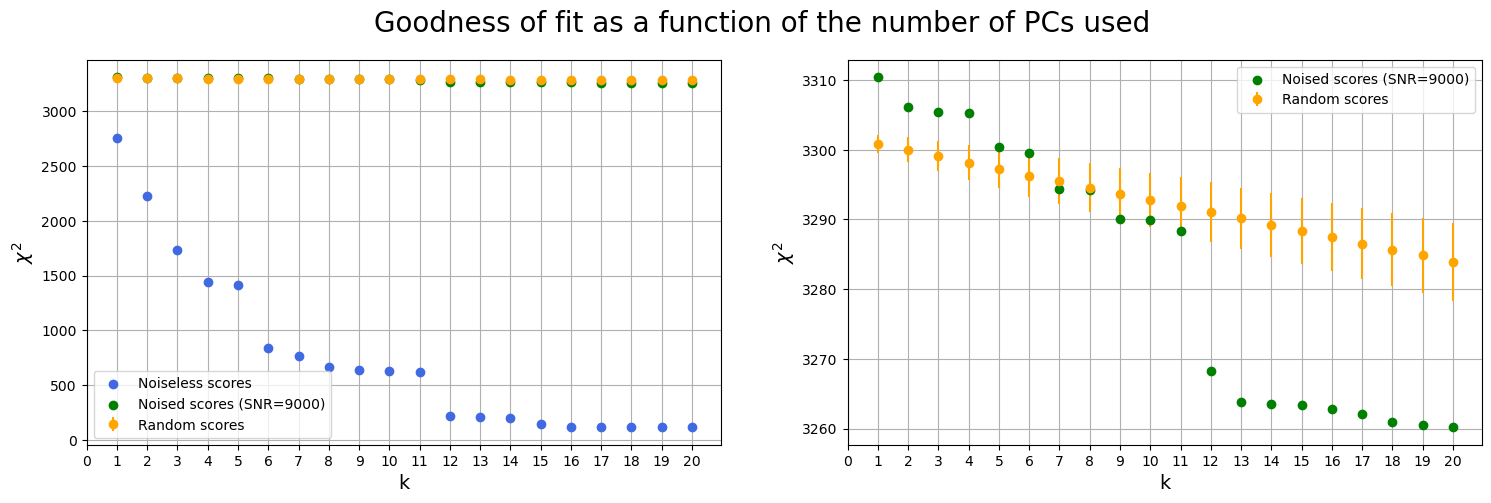

In [35]:
# add noise by repeating random draws and duplicate the absorption line (N times)
fig, axs = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Goodness of fit as a function of the number of PCs used', size=20)

axs[0].grid()
axs[0].scatter(k_list, chi2_list[:, 0], label='Noiseless scores', color='royalblue', zorder=2)
axs[0].errorbar(k_list, chi2_list[:, 1], yerr=chi2_list[:, 2], label='Random scores', color='orange', ecolor='orange', fmt='o', zorder=2)
axs[0].scatter(k_list, chi2_list_noisy, label=f'Noised scores (SNR={snr})', color='green', zorder=2)
axs[0].set_xlabel('k', size=14)
axs[0].set_ylabel(r'$\chi^2$', size=14)
axs[0].set_xticks(np.arange(0, n_components + 1, 1))
axs[0].legend()
#axs[0].set_yscale('log')

axs[1].grid()
axs[1].errorbar(k_list, chi2_list[:, 1], yerr=chi2_list[:, 2], label='Random scores', color='orange', ecolor='orange', fmt='o', zorder=2)
axs[1].scatter(k_list, chi2_list_noisy, label=f'Noised scores (SNR={snr})', color='green', zorder=2)
axs[1].set_xlabel('k', size=14)
axs[1].set_ylabel(r'$\chi^2$', size=14)
axs[1].set_xticks(np.arange(0, n_components + 1, 1))
axs[1].legend()

plt.show()

In [36]:
# calculate chi2 for several SNR
C_0 = 1000  # continuum constant (for TM)
snr = [1e4, 1e5, 1e6, 1e7, 1e8, 1e9]
results = []
for snr_i in tqdm(snr):  # for each SNR
    # add noise to the original TS
    spectra_noisy = spectra + np.random.normal(0, 1/snr_i, spectra.shape)
    # calculate RV
    mean_spec_i = np.mean(spectra_noisy, axis=0)
    rv_i = np.array([t.calculate_rv(wl, mean_spec_i, row, C_0) for row in spectra_noisy])
    # preprocessing
    S_f_i, D_i = t.subtract_D(wl, spectra_noisy, c=c)
    spectra_centered_i = t.double_centering(S_f_i)
    # apply PCA
    pca_i = PCA(n_components=n_components)  # create PCA object
    pcs_i = pca_i.fit_transform(spectra_centered_i)
    scores_i = np.array([pcs_i[:, j] for j in range(n_components)])
    # calculate chi2
    chi2 = []
    for k in k_list:
        chi2.append(t.calculate_chi2(k, scores_i, rv_i))
    chi2 = np.array(chi2)  # array of chi2 for each k
    chi2_y = np.linalg.norm(rv_i)**2  # float
    f_k = 1 - chi2 / chi2_y  # array
    results.append([snr_i, chi2, chi2_y, f_k])

df_noise = pd.DataFrame(results, columns=['SNR', 'chi2', 'chi2_y', 'f_k'])

100%|██████████| 6/6 [00:02<00:00,  2.73it/s]


In [37]:
chi2_snr = df_noise['chi2'].to_numpy()
snr = df_noise['SNR'].to_numpy()

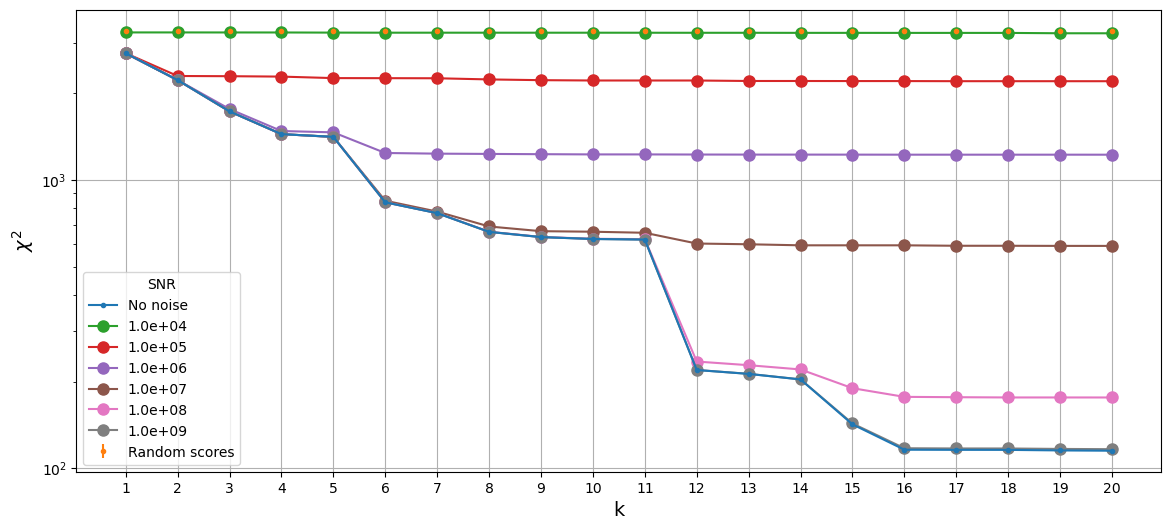

In [38]:
# show chi2 vs k for several SNR
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(k_list, chi2_list[:, 0], marker='.', label='No noise', zorder=100)
ax.errorbar(k_list, chi2_list[:, 1], yerr=chi2_list[:, 2], label='Random scores', fmt='.', zorder=99)
for i in range(len(chi2_snr)):
    ax.plot(k_list, chi2_snr[i], marker='o', markersize=8, label=f'{snr[i]:.1e}')
ax.grid(True)

ax.set_yscale('log')
ax.set_xlabel('k', size=14)
ax.set_xticks(k_list)
ax.set_ylabel(r'$\chi^2$', size=14)

ax.legend(title='SNR')
plt.show()

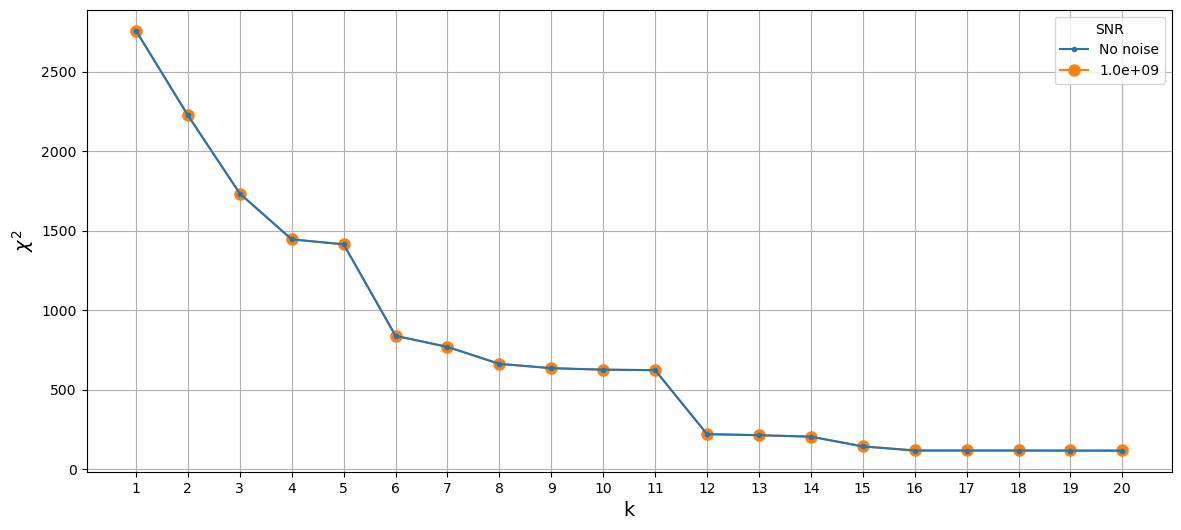

In [39]:
# show only with SNR=1e9
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(k_list, chi2_list[:, 0], marker='.', label='No noise', zorder=100)
ax.plot(k_list, chi2_snr[-1], marker='o', markersize=8, label=f'{snr[-1]:.1e}')
ax.grid(True)

ax.set_xlabel('k', size=14)
ax.set_xticks(k_list)
ax.set_ylabel(r'$\chi^2$', size=14)

ax.legend(title='SNR')
plt.show()

/home/elefevre-forjan/.conda/envs/internship/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/elefevre-forjan/.conda/envs/internship/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


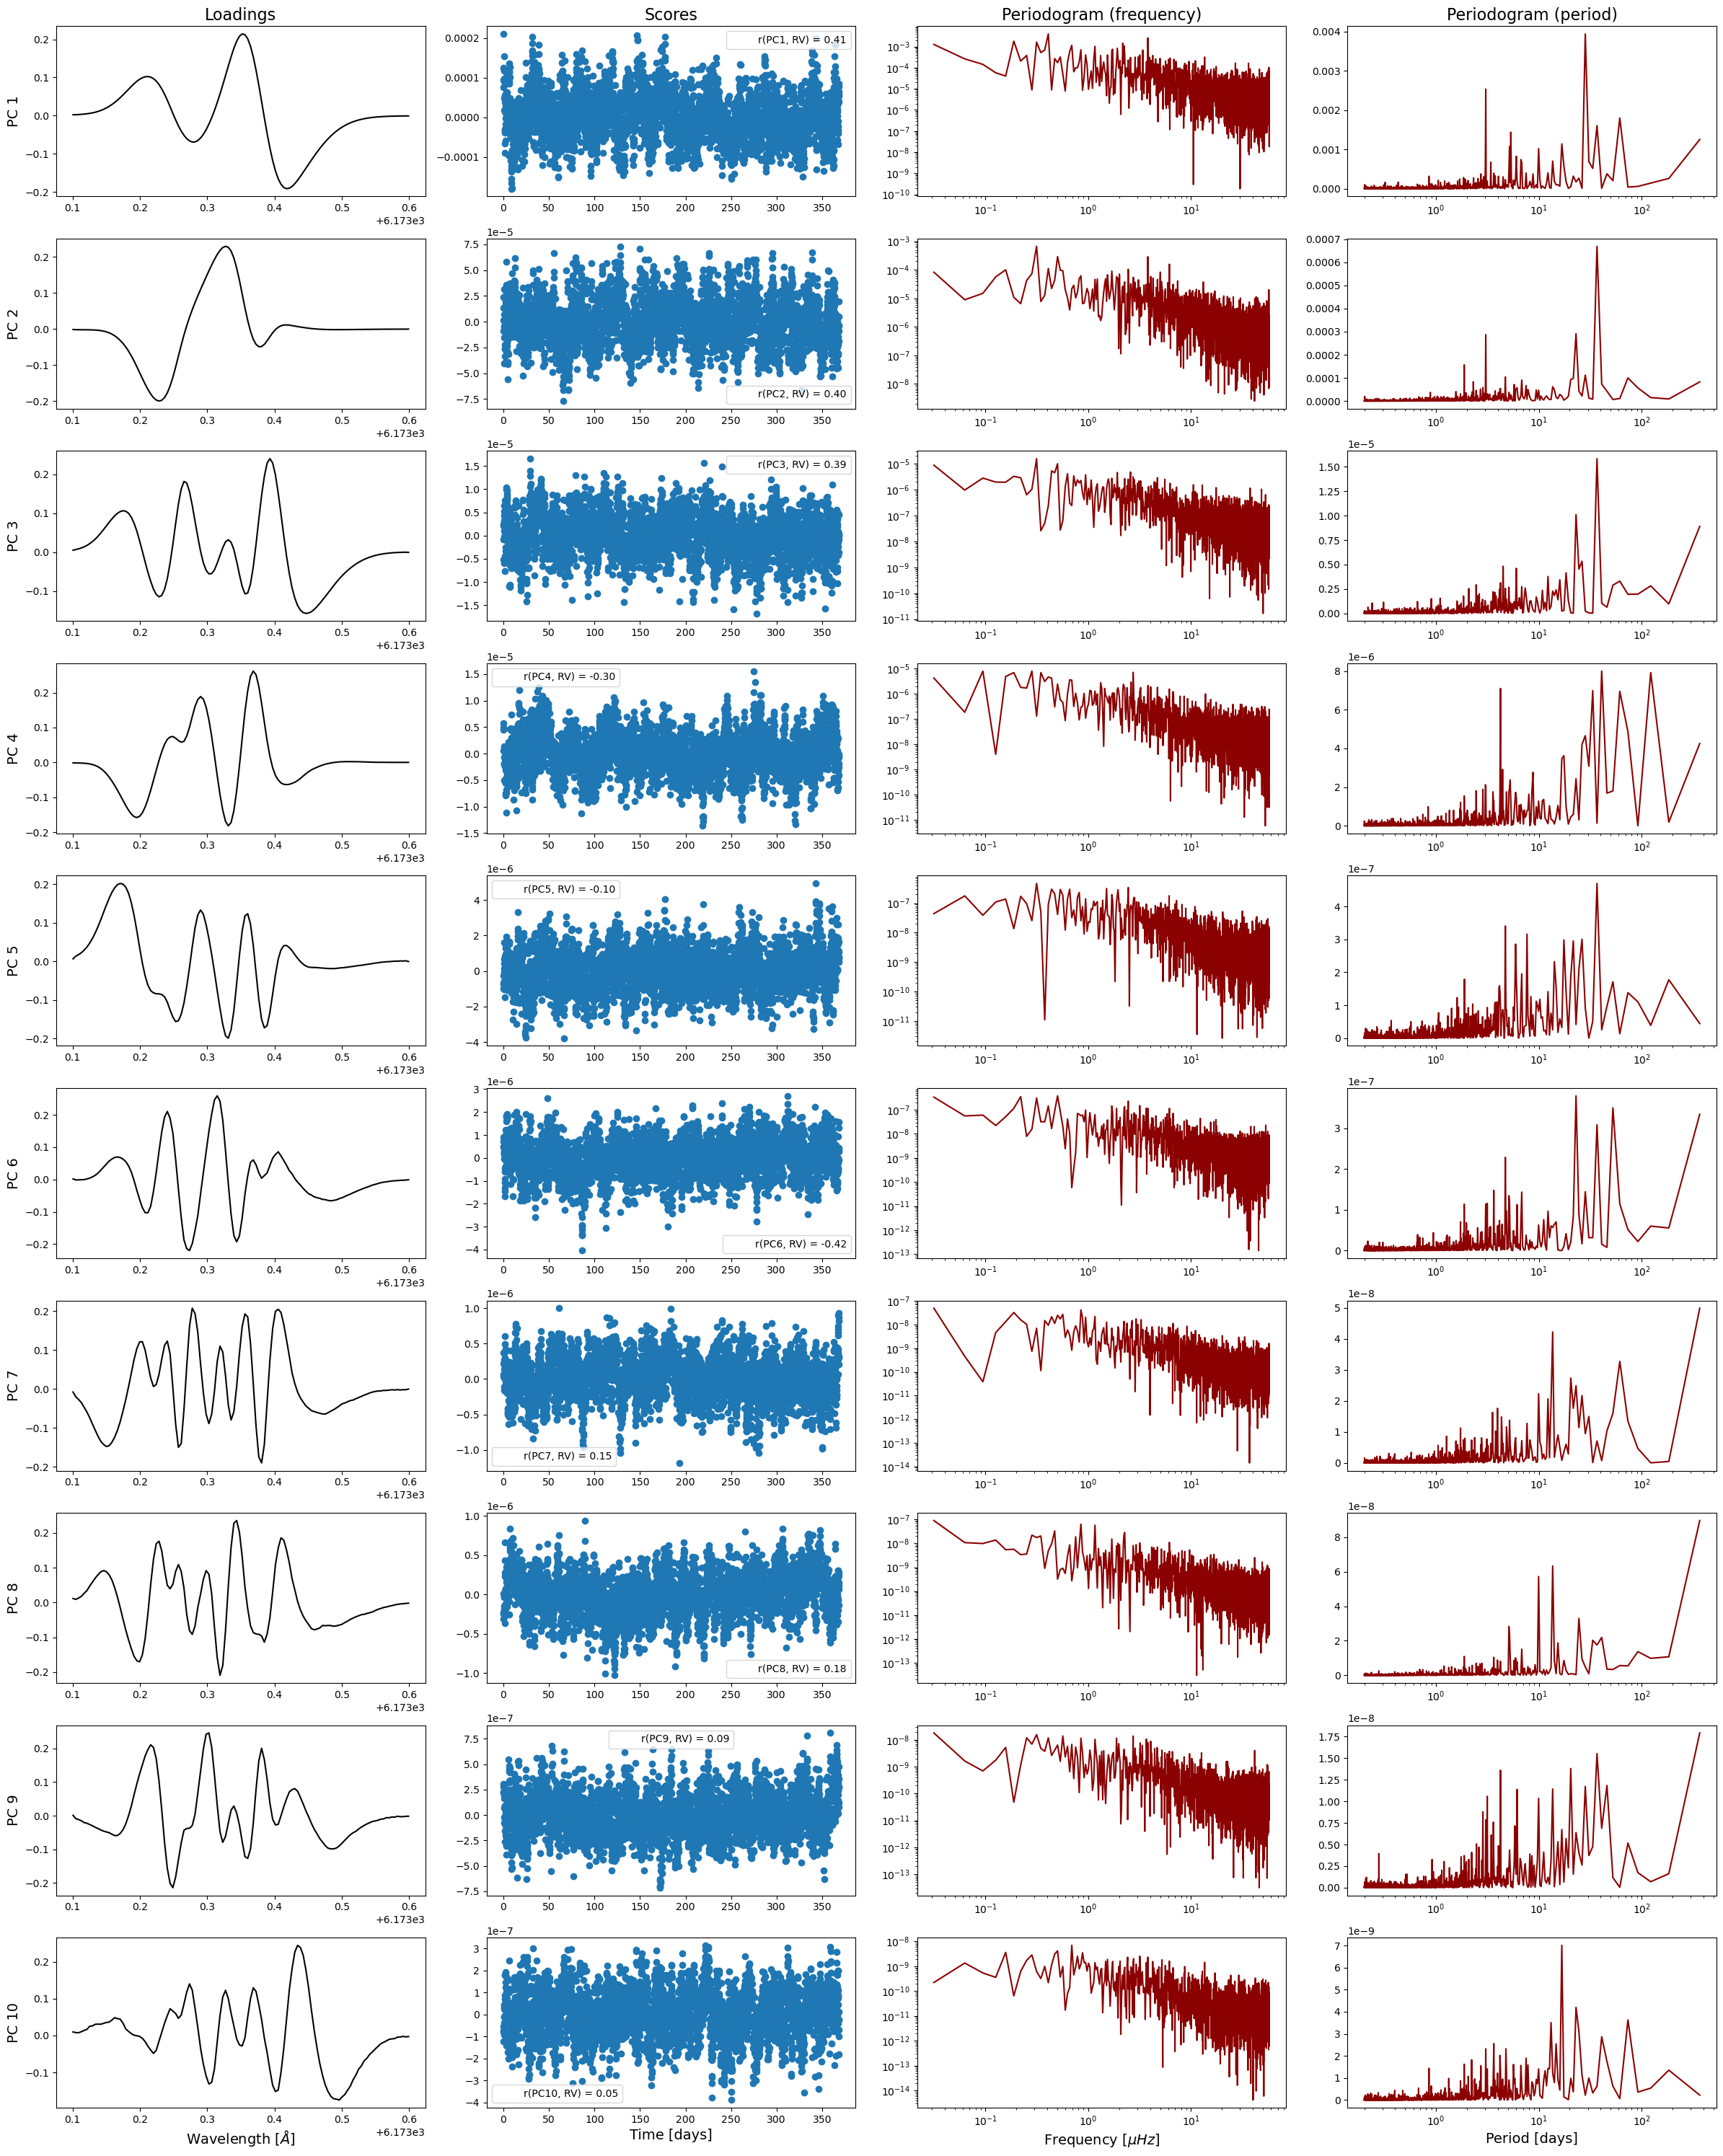

In [40]:
# show loadings, scores and periodograms of the TS
N_pcs = 10
j_pcs = np.arange(0, 10, 1)  # change this line to show other PCs

fig, axs = plt.subplots(N_pcs, 4, figsize=(24, 3 * N_pcs))

for i in range(N_pcs):
    j = j_pcs[i]
    if i == min(range(N_pcs)):
        axs[i][0].set_title('Loadings', size=16)
        axs[i][1].set_title('Scores', size=16)
        axs[i][2].set_title('Periodogram (frequency)', size=16)
        axs[i][3].set_title('Periodogram (period)', size=16)
    if i == max(range(N_pcs)):
        axs[i][0].set_xlabel(r'Wavelength [$\AA$]', size=14)
        axs[i][1].set_xlabel('Time [days]', size=14)
        axs[i][2].set_xlabel(r'Frequency [$\mu Hz$]', size=14)
        axs[i][3].set_xlabel('Period [days]', size=14)
        
    # Loadings
    axs[i][0].plot(wl, loadings[j], color='k')
    axs[i][0].set_ylabel(f'PC {j + 1}', size=14)
    
    # Scores
    axs[i][1].scatter(times, scores[j])
    r = corr_ts[file][j]
    axs[i][1].scatter(np.median(times), np.median(scores[j]), color='w', marker='.', label=f'r(PC{j + 1}, RV) = {r:.2f}', zorder=-1)  # show correlation coefficient
    axs[i][1].legend()

    # Fourier power spectrum (frequency)
    mask = freq[j] > 0
    axs[i][2].plot(freq[j][mask] * 10**6, ps[j][mask], color='darkred')  # frequency in Hz multiplied by 10^6 to pass to microhertz
    axs[i][2].set_yscale('log')
    axs[i][2].set_xscale('log')
    
    # Fourier periodogram (period)
    axs[i][3].plot(1 / (freq[j][mask] * 86400), ps[j][mask], color='darkred')  # frequency in Hz divided by 86400 to pass from to days^-1
    #axs[i][3].set_yscale('log')
    axs[i][3].set_xscale('log')

fig.tight_layout()
plt.show()

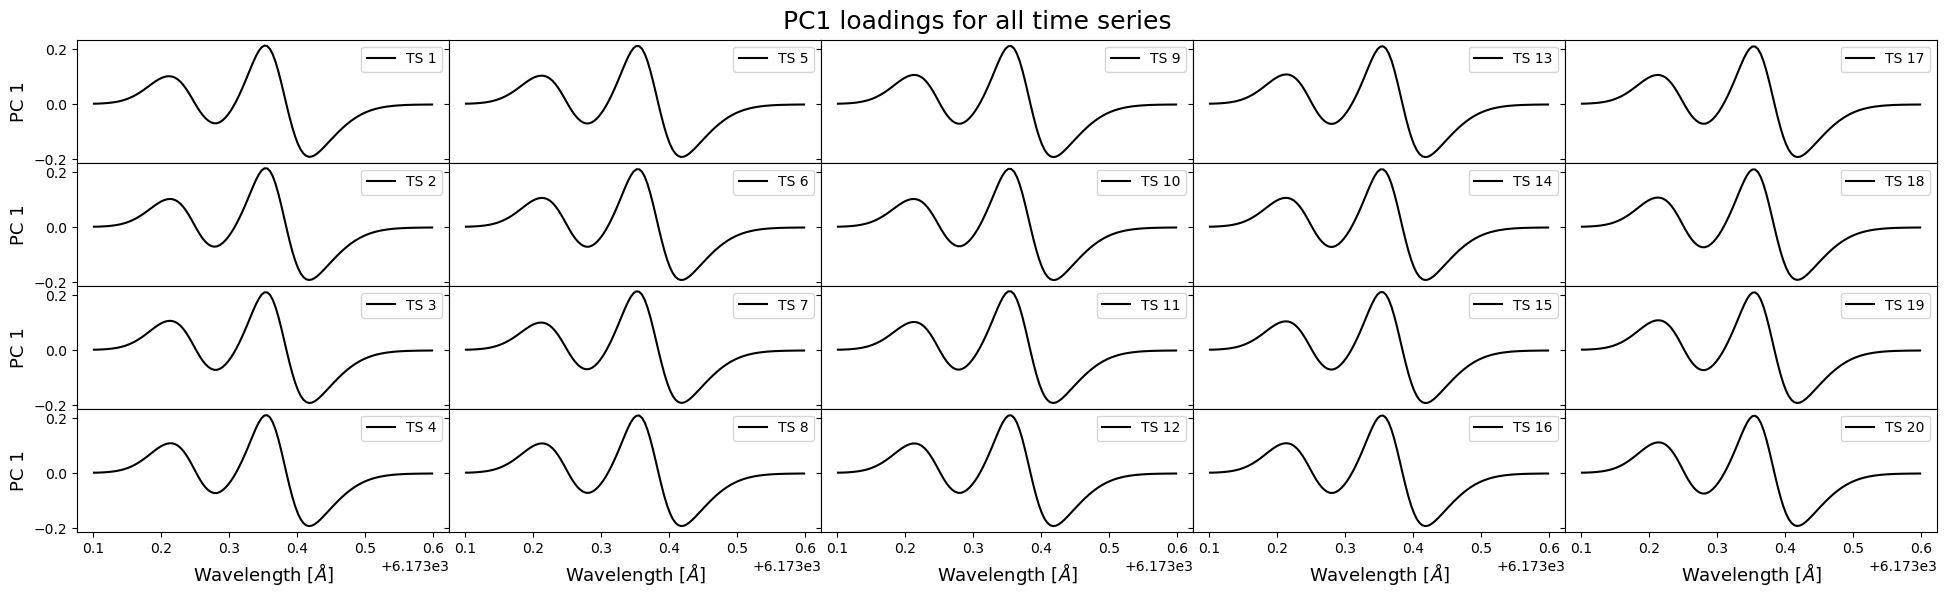

In [41]:
# PC-i loadings have always the same shape?
pc_index = 0

rows = 4
cols = 5
fig, axs = plt.subplots(rows, cols, figsize=(24, 6), sharex=True, sharey=True)
fig.suptitle(f'PC{pc_index + 1} loadings for all time series', size=18)

r = 0
k = -1

for i in range(N_files):  # iterate over the N_files time series of spectra
    if i % rows == 0:  # if the column is filled, advance to the next one
        k += 1  # advance to the next column
        r = 0  # reset row
    if k == 0:  # set y-label only in the first column of each row
        axs[r][k].set_ylabel(f'PC {pc_index + 1}', size=13)
    if r + 1 == rows:  # set x-label only in the last row of each column
        axs[r][k].set_xlabel(r'Wavelength [$\AA$]', size=13)
    axs[r][k].plot(wl, loadings_ts[i][pc_index], color='k', label=f'TS {i + 1}')
    axs[r][k].legend()
    r += 1  # advance to the next row

plt.subplots_adjust(hspace=0, wspace=0, top=.93)
plt.show()

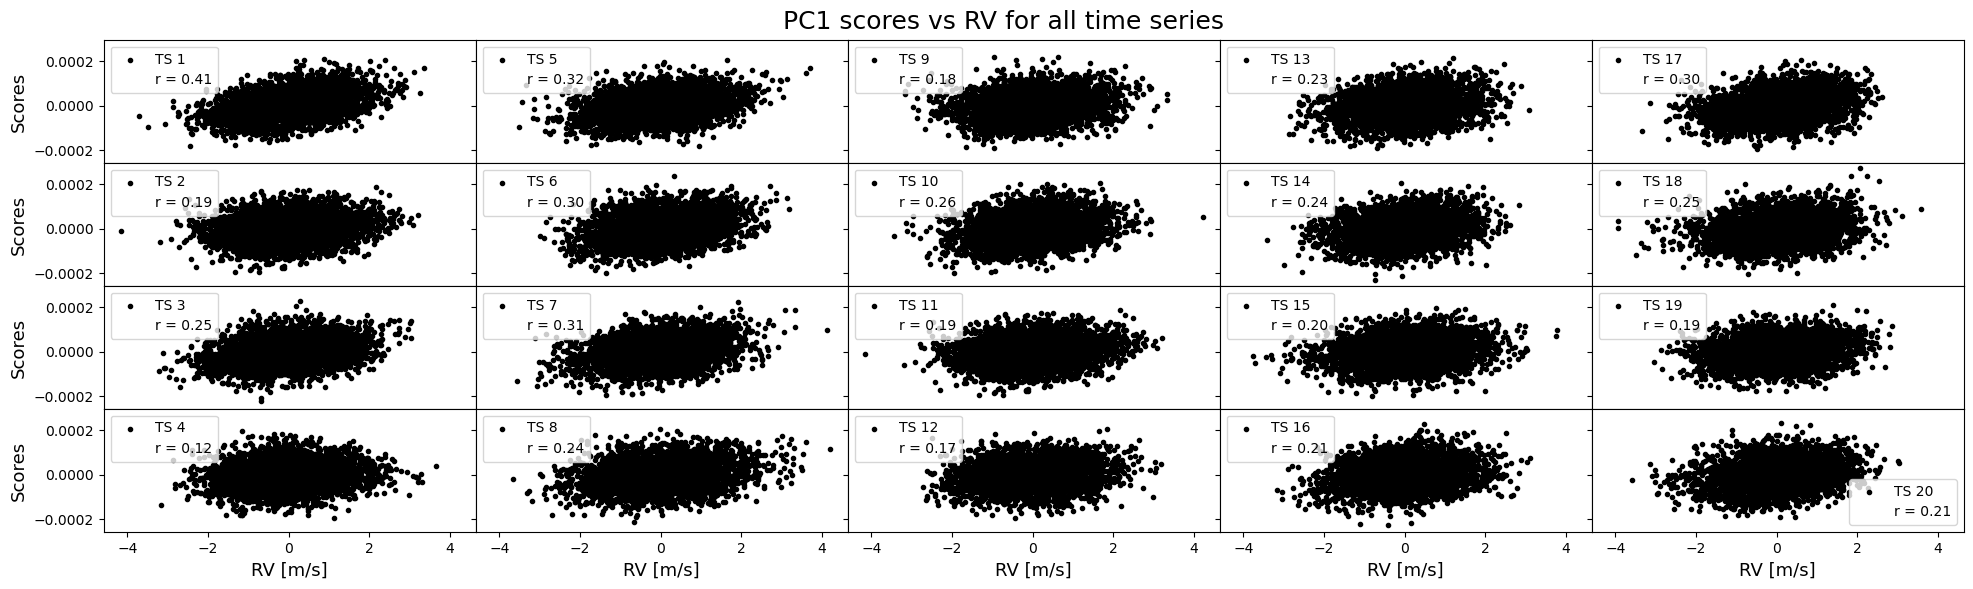

In [42]:
# PC1 always correlated with RV?
rows = 4
cols = 5
fig, axs = plt.subplots(rows, cols, figsize=(24, 6), sharex=True, sharey=True)
fig.suptitle('PC1 scores vs RV for all time series', size=18)

r = 0
k = -1

for i in range(N_files):  # iterate over the N_files time series of spectra
    if i % rows == 0:  # if the column is filled, advance to the next one
        k += 1  # advance to the next column
        r = 0  # reset row
    if k == 0:  # set y-label only in the first column of each row
        axs[r][k].set_ylabel('Scores', size=13)
    if r + 1 == rows:  # set x-label only in the last row of each column
        axs[r][k].set_xlabel('RV [m/s]', size=13)
    axs[r][k].scatter(rv_tm[i], scores_ts[i][0], color='k', label=f'TS {i + 1}', marker='.')
    axs[r][k].axvline(0, color='w', label=f'r = {ss.pearsonr(scores_ts[i][0], rv_tm[i])[0]:.2f}', zorder=-1)
    axs[r][k].legend()
    r += 1  # advance to the next row

plt.subplots_adjust(hspace=0, wspace=0, top=.93)
plt.show()

In [43]:
# are PCs always orthogonal to D?
dot_prod = []  # each element is a list of the dot products between D and each PC of a certain TS

for i in range(N_files):  # iterate over TS
    D = D_vectors[i]      # extract the corresponding Doppler vector (D_vectors was calculated in the Preprocessing, at the beginning of the notebook)
    dp = []
    for j in range(n_components):  # iterate over PCs
        dp.append(np.dot(D, loadings_ts[i][j]))  # save dot product
    dot_prod.append(dp)

dot_prod = np.array(dot_prod)

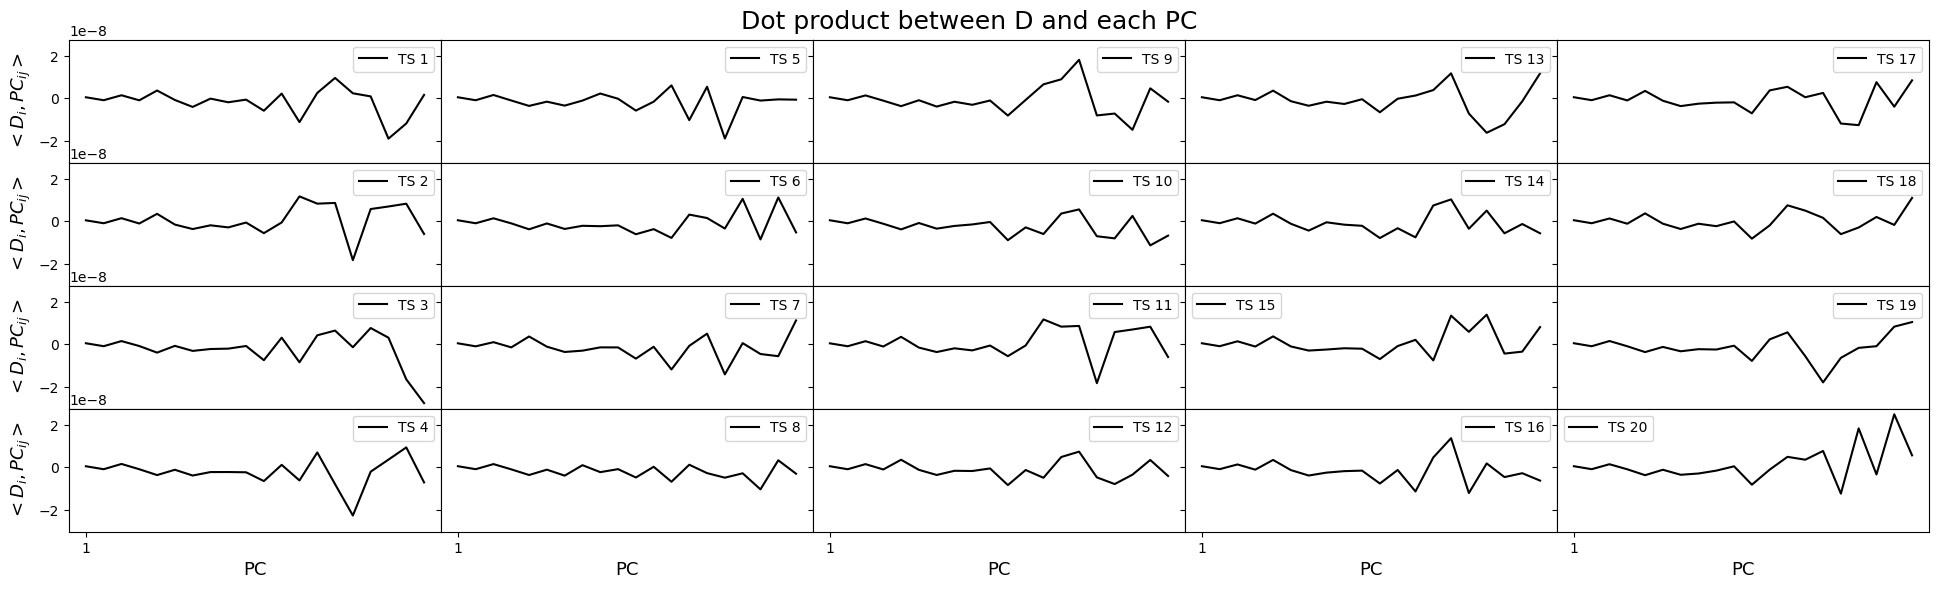

In [46]:
# show dot product between PC loadings and Doppler vector
# plot

rows = 4
cols = 5
fig, axs = plt.subplots(rows, cols, figsize=(24, 6), sharex=True, sharey=True)
fig.suptitle('Dot product between D and each PC', size=18)

r = 0
k = -1

for i in range(N_files):  # iterate over the N_files TS of spectra
    if i % rows == 0:  # if the column is filled, advance to the next one
        k += 1  # advance to the next column
        r = 0  # reset row
    if k == 0:  # set y-label only in the first column of each row
        axs[r][k].set_ylabel(r'$<D_i, PC_{ij}>$', size=13)
    if r + 1 == rows:  # set x-label only in the last row of each column
        axs[r][k].set_xlabel('PC', size=13)
    axs[r][k].plot(np.linspace(1, N_files, 20), dot_prod[i], color='k', label=f'TS {i + 1}')
    axs[r][k].set_xticks(np.arange(1, n_components + 1, n_components))
    axs[r][k].legend()
    r += 1  # advance to the next row

plt.subplots_adjust(hspace=0, wspace=0, top=.93)
plt.show()

In [47]:
# find strong correlations
threshold = .5  # correlations higher than this threshold will be printed
for i in range(N_files):
    for j in range(n_components):
        r, p = ss.pearsonr(scores_ts[i][j], rv_tm[i])
        if np.abs(r) > threshold:
            print(f'PC {j+1} from TS {i+1} is correlated with the radial velocity: r={r:.2f}')
            #print(f'pvalue={p}')

PC 6 from TS 19 is correlated with the radial velocity: r=-0.50


In [48]:
# reconstruct spectrum from PCs
# reconstructed spectrum is mean spectrum + PCs
mean_Sf = np.mean(S_f[file], axis=0)
rec_spec = np.tile(mean_Sf, (len(scores[file]), 1))  # array of 3686 mean_Sf
row_means = np.mean(S_f[file] - mean_Sf, axis=1)

for i in range(n_components):
    spec_i = []  # spectrum over time reconstructed only from the PC-i
    for j in range(len(scores[i])):
        spec_j = scores[i][j] * loadings[i]  # spectrum at timestep j reconstructed only from the PC-i
        spec_i.append(spec_j)
    spec_i = np.array(spec_i)
    rec_spec += spec_i

rec_spec += row_means[:, None]
difference = S_f[file] - rec_spec  # difference between the original TS (after preprocessing) and the reconstructed one

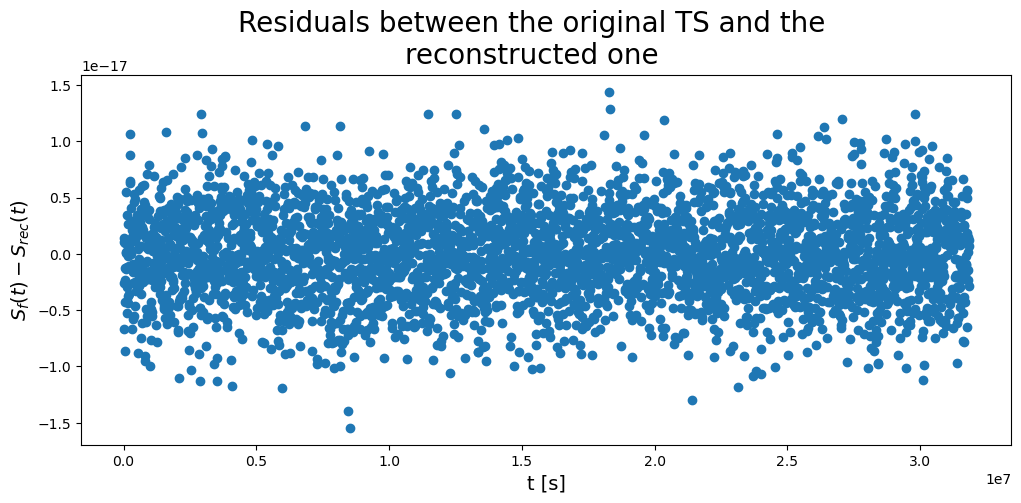

In [49]:
# show difference (residuals are small)
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Residuals between the original TS and the\nreconstructed one', size=20)

ax.scatter(times_sec, np.mean(difference, axis=1))
ax.set_xlabel('t [s]', size=14)
ax.set_ylabel(r'$S_f(t) - S_{rec}(t)$', size=14)

plt.subplots_adjust(top=.85)
plt.show()